<a href="https://colab.research.google.com/github/CrayZeeQueue/6m-data-3.8-Computer-Vision/blob/main/notebooks/03_first_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/su-ntu-ctp/6m-data-3.8-Computer-Vision/blob/main/notebooks/03_first_cnn.ipynb)

**Where to run this notebook**

- **Locally (VS Code + Jupyter)**: just open the notebook and pick the `dsai-m3` kernel if you have a dedicated GPU, otherwise recommend using the Colab option below.
- **Colab (recommended if you don't have a dedicated GPU)**: click the badge above, then **Runtime → Change runtime type → T4 GPU**, then run the setup cell below. It clones the repo, installs missing deps, and `cd`s into the right working directory.


In [1]:
# === Colab-compat setup (no-op when running locally) ===
# This cell makes the notebook work both on your own machine AND on Google Colab.
# It detects where it's running. If on Colab, it downloads the course code from GitHub,
# moves into the right folder, and installs a couple of extra libraries.
# If you're running locally, it does almost nothing (just sets a few safe defaults).
import os, sys
## NEW FOR GPU.
## Deep Learning libraries (like PyTorch) and Math libraries (like NumPy) both try to load a library called
## "OpenMP" to use multiple CPU cores. On a Mac, if two different packages accidentally try to load OpenMP
## at the exact same time, the Mac panics, instantly kills the Python process, and refuses to run.
## This causes VS Code to just throw up its hands and say, "The Kernel died!"
## Hence, we need to tell OpenMP it's okay to load multiple copies of itself. This is harmless, and it prevents
## the crash.
## As such the following line is a workaround for a Mac-specific bug. It has no effect on Linux or Windows.
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import torch

# `sys.modules` lists everything Python has loaded. Colab loads a special "google.colab"
# module, so this is a reliable way to ask "am I on Colab right now?"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/su-ntu-ctp/6m-data-3.8-Computer-Vision.git"
    REPO_DIR = "/content/6m-data-3.8-Computer-Vision"
    LESSON_DIR = "notebooks"

    # Only clone (download) the repo if we haven't already, so re-running is cheap.
    if not os.path.exists(REPO_DIR):
        print(f"Cloning repo into {REPO_DIR} ...")
        os.system(f"git clone -q {REPO_URL} {REPO_DIR}")

    # Move into the lesson folder so relative paths (like 'data/...') resolve correctly.
    os.chdir(f"{REPO_DIR}/{LESSON_DIR}")
    print(f"Working directory: {os.getcwd()}")

    ## NEW FOR GPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Colab has torch + torchvision pre-installed. Install the rest.
    os.system("pip install -q sentence-transformers transformers")
    print("Colab setup done.")
else:
    ## NEW FOR GPU. If no GPU detected, fall back to CPU.
    device = 'cpu'

## NEW FOR GPU.
print(f"Using device: {device}")

# Threading caps — set here for both local and Colab runs (no .env file needed).
# These environment variables tell math libraries to use a single CPU thread, which keeps
# runs reproducible and avoids slowdowns from over-threading on small workloads.
# setdefault only sets a value if it isn't already set, so this is harmless if already configured.
# (Loop form prevents Jupyter from auto-displaying the return value.)
for _key, _val in [("OMP_NUM_THREADS", "1"), ("MKL_NUM_THREADS", "1"), ("TOKENIZERS_PARALLELISM", "false")]:
    os.environ.setdefault(_key, _val)


Cloning repo into /content/6m-data-3.8-Computer-Vision ...
Working directory: /content/6m-data-3.8-Computer-Vision/notebooks
Colab setup done.
Using device: cuda


# L08 · NB 03 — Your first CNN

> *We watched kernels work by hand. Now let's let PyTorch learn them.*

**Why this notebook?** In NB 01, Sarah's flatten-and-MLP approach hit a wall: ~87% accuracy, and worse, its parameter count explodes as images get bigger (a 224×224 colour photo would need ~38M weights in the first layer alone). The problem is that an MLP treats pixels as an unordered list — it throws away the fact that nearby pixels are related and that a sleeve is a sleeve wherever it appears. In NB 02 we saw the fix by hand: convolution, which slides a small reusable filter across the image. **This notebook turns that idea into a real, trainable model and proves it beats the MLP.**

**What you'll build:** a small Convolutional Neural Network (`TinyCNN`) — two `Conv → ReLU → MaxPool` blocks that extract visual features, followed by a classifier head that turns those features into a clothing-category prediction. You'll train it on Fashion-MNIST and put it head-to-head with the MLP baseline.

By the end of this notebook you will have:

1. Built a 2-block CNN (`Conv → ReLU → MaxPool`) in PyTorch
2. Trained it on Fashion-MNIST
3. Compared its accuracy AND parameter count against the MLP baseline from NB 01
4. Visualised what the **first conv layer learned** — actual filters after training

**The key takeaway you're working toward:** a CNN reaches *higher* accuracy with *fewer* parameters than the MLP, because it exploits the spatial structure of images instead of ignoring it.

The training loop is identical to L07's. The only thing that changes is the model definition — that's the whole point: once you can define a model, the rest of the deep-learning workflow you already know carries straight over.

## 1 · Setup

In [2]:
# Setup: import our tools, lock in randomness for reproducibility, and load the dataset.
# Fashion-MNIST is 70,000 tiny (28x28) grayscale images of clothing in 10 categories.
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn                       # nn = neural-network building blocks (layers, losses)
import torchvision.transforms as T          # tools to convert/prepare images for the model
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader     # feeds data to the model in batches

torch.set_num_threads(1)                    # use one CPU thread -> consistent, reproducible runs
# Fix the random "seed" so shuffling and weight initialisation are the same every run.
# Without this, you'd get slightly different numbers each time you run the notebook.
torch.manual_seed(42)
np.random.seed(42)

# ToTensor() converts an image into a PyTorch tensor and scales pixel values from 0-255 down to 0.0-1.0.
transform = T.ToTensor()
# Download the data once (cached in data/fmnist) and split into a training set and a test set.
train_ds = FashionMNIST(root='data/fmnist', train=True,  download=True, transform=transform)
test_ds  = FashionMNIST(root='data/fmnist', train=False, download=True, transform=transform)
CLASSES = train_ds.classes                  # human-readable names like "T-shirt/top", "Coat", ...

print(f"Train: {len(train_ds):,}  |  Test: {len(test_ds):,}")

Train: 60,000  |  Test: 10,000


## 2 · TinyCNN — two conv blocks + classifier head

This is the architecture from `lesson.md`. Read each layer in plain English:

1. **Block 1**: 1-channel input → 16 feature maps, each 28×28, then ReLU, then halve to 14×14.
2. **Block 2**: 16 channels → 32, each 14×14, ReLU, halve to 7×7.
3. **Head**: flatten the 32×7×7 = 1568 features, run through 64-unit hidden layer, then output 10 logits.

In [5]:
# Define our CNN (Convolutional Neural Network). A CNN looks at small patches of an image
# with little learnable filters ("kernels") that slide across the picture to spot edges, textures, etc.
# We build it in two parts: "features" (find visual patterns) and "classifier" (decide the category).
class TinyCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # nn.Sequential just runs these layers one after another, top to bottom.
        self.features = nn.Sequential(
            # Conv2d: a convolution layer. 1 input channel (grayscale) -> 16 output "feature maps".
            # kernel_size=3 means each filter is a 3x3 patch; padding=1 keeps the image size at 28x28.
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),                 # ReLU: keep positive values, set negatives to 0 (adds non-linearity)
            nn.MaxPool2d(2),           # MaxPool: shrink each 2x2 block to its max value -> 28x28 becomes 14x14
            # Second block: take the 16 feature maps and produce 32 richer ones.
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),           # halves the size again: 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),              # turn the 32 x 7 x 7 grid into one long 1568-number vector
            # Linear (fully connected) layer: maps 1568 features down to 64.
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),  # final layer: 64 -> 10 scores ("logits"), one per clothing class
        )
    def forward(self, x):
        # forward() defines how data flows: first extract features, then classify them.
        return self.classifier(self.features(x))

cnn = TinyCNN()
## NEW FOR GPU: Push model BEFORE optimizer.
cnn = cnn.to(device)
# Count every learnable number (weight) in the model. .numel() = number of elements in a tensor.
n_params = sum(p.numel() for p in cnn.parameters())
print(f"TinyCNN parameter count: {n_params:,}")
print(cnn)                              # prints a readable summary of the layers

TinyCNN parameter count: 105,866
TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


**~110K parameters** — about half the MLP's 235K. And these parameters are *position-independent*: the same kernel slides everywhere. We'll see in a minute that it learns more from the same data.

## 3 · Sanity-check the forward pass

Before training, run a dummy batch through to confirm shapes line up at every layer. This catches off-by-one errors before you waste an hour training.

In [6]:
# Sanity check: push a fake ("dummy") batch through the untrained model just to confirm
# the shapes line up. This catches wiring mistakes before we spend time training.

## NEW FOR GPU: Push dummy tensor to match model (batch, channels, height, width)
dummy = torch.randn(4, 1, 28, 28).to(device) # 4 random images, 1 channel, 28x28 pixels (batch, channels, height, width)
# torch.no_grad() = "don't track gradients" — we're just checking shapes, not learning, so this is faster.
with torch.no_grad():
    out = cnn(dummy)
print(f"Input batch shape : {dummy.shape}")
# We expect 4 rows (one per image) and 10 columns (one score per class).
print(f"Output logits shape: {out.shape}  # (batch, n_classes)")

Input batch shape : torch.Size([4, 1, 28, 28])
Output logits shape: torch.Size([4, 10])  # (batch, n_classes)


## 4 · Train the CNN

Same training loop as L07 NB 04. The model is different, the loop is not.

In [7]:
# Train the CNN. "Training" means: show it batches of images, let it guess, measure how wrong
# it is, and nudge its weights to be a little less wrong — repeated over and over.
BATCH = 256        # how many images the model looks at before updating its weights
EPOCHS = 5         # how many full passes over the whole training set
LR = 1e-3          # learning rate: how big each weight-update step is (too big = unstable, too small = slow)

# DataLoaders hand us the data in batches. Shuffle the training data each epoch so the model
# doesn't just memorise the order; no need to shuffle the test set.
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

# Adam is a popular optimizer — it's the algorithm that actually adjusts the weights.
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)
# CrossEntropyLoss measures how wrong the predictions are for a classification task.
criterion = nn.CrossEntropyLoss()

# Helper to measure accuracy: what fraction of test images does the model label correctly?
def evaluate(model, loader):
    model.eval()                 # eval mode: turn off training-only behaviour
    correct = 0
    total = 0
    with torch.no_grad():        # no learning here, just predicting -> faster
        for xb, yb in loader:    # xb = batch of images, yb = their true labels
            ## NEW FOR GPU: Move the data to GPU before evaluation starts.
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            # argmax picks the class with the highest score; compare to the true label.
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
    return correct / total

cnn_history = []                 # store (epoch, loss, accuracy) so we can review progress later
t0 = time.time()                 # start a timer
for epoch in range(1, EPOCHS + 1):
    cnn.train()                  # training mode
    running = 0.0                # accumulate total loss for this epoch
    for xb, yb in train_loader:
        ## NEW FOR GPU: Move the data to GPU before training starts.
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()    # clear leftover gradients from the previous step
        loss = criterion(cnn(xb), yb)  # forward pass + measure error
        loss.backward()          # backpropagation: compute how each weight affected the error
        optimizer.step()         # update the weights using those gradients
        running += loss.item() * xb.size(0)  # weight loss by batch size so the average is fair
    train_loss = running / len(train_ds)     # average loss over the epoch
    acc = evaluate(cnn, test_loader)          # check accuracy on unseen test data
    cnn_history.append((epoch, train_loss, acc))
    print(f"epoch {epoch} | train loss {train_loss:.4f} | test acc {acc:.4f}")
print(f"\nTotal training time: {time.time()-t0:.1f}s")

epoch 1 | train loss 0.7051 | test acc 0.8124
epoch 2 | train loss 0.4184 | test acc 0.8518
epoch 3 | train loss 0.3593 | test acc 0.8670
epoch 4 | train loss 0.3273 | test acc 0.8785
epoch 5 | train loss 0.3049 | test acc 0.8833

Total training time: 45.5s


## 5 · Compare to the MLP baseline

The MLP from NB 01 was about 87% accurate. What did the CNN buy us?

In [8]:
# For a fair comparison, train a plain MLP (multi-layer perceptron) on the same data.
# An MLP ignores spatial structure: it flattens the image into a flat list of pixels and treats
# them as unrelated numbers. This shows what the CNN's "look at patches" approach actually buys us.
class FlatMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),            # turn the 28x28 image into a flat 784-number vector
            nn.Linear(784, 256),     # fully connected layers — every pixel connects to every neuron
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),      # final 10 class scores
        )
    def forward(self, x):
        return self.net(x)

mlp = FlatMLP()
## NEW FOR GPU: Push model BEFORE optimizer.
mlp = mlp.to(device)
mlp_optim = torch.optim.Adam(mlp.parameters(), lr=LR)

# Same training loop as before, just for the MLP. (We skip per-epoch printing to keep it short.)
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    mlp.train()
    for xb, yb in train_loader:
        ## NEW FOR GPU: Move the data to GPU before training starts.
        xb, yb = xb.to(device), yb.to(device)
        mlp_optim.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward()
        mlp_optim.step()
mlp_time = time.time() - t0
mlp_acc = evaluate(mlp, test_loader)                    # MLP accuracy on the test set
mlp_params = sum(p.numel() for p in mlp.parameters())   # how many weights the MLP has

cnn_acc = evaluate(cnn, test_loader)                    # re-check the CNN's accuracy for the table

# Print a tidy side-by-side comparison table.
print(f"{'Model':10} {'Params':>10} {'Test acc':>10}")
print(f"{'-'*32}")
print(f"{'FlatMLP':10} {mlp_params:>10,} {mlp_acc:>10.4f}")
print(f"{'TinyCNN':10} {n_params:>10,} {cnn_acc:>10.4f}")
# The headline: the CNN is more accurate while using far fewer parameters.
print(f"\nCNN improvement: {(cnn_acc - mlp_acc)*100:+.2f}% accuracy at {n_params/mlp_params*100:.0f}% of the parameter count")

Model          Params   Test acc
--------------------------------
FlatMLP       235,146     0.8661
TinyCNN       105,866     0.8833

CNN improvement: +1.72% accuracy at 45% of the parameter count


The CNN gets **higher accuracy with less than half the parameters**. On this run it's roughly +1.4 percentage points (e.g. 88.4% vs 87.1%). That's about a 10% relative reduction in error — modest on this easy dataset, but achieved with **45% of the parameters**.

As image complexity grows (colour, higher resolution, more classes), the gap widens dramatically — on CIFAR-10 (the assignment dataset) you'll see a CNN beat an MLP by 10+ points.

## 6 · Where does the CNN do better?

Let's look at the confusion matrix. The shirt-like categories — T-shirt/top (0), Pullover (2), Coat (4), Shirt (6) — are the hardest to tell apart, because at 28×28 they share the same rough silhouette. Read each matrix row as "of all the real Xs, what fraction did the model predict as each class?" — the **diagonal** is the fraction it got right.

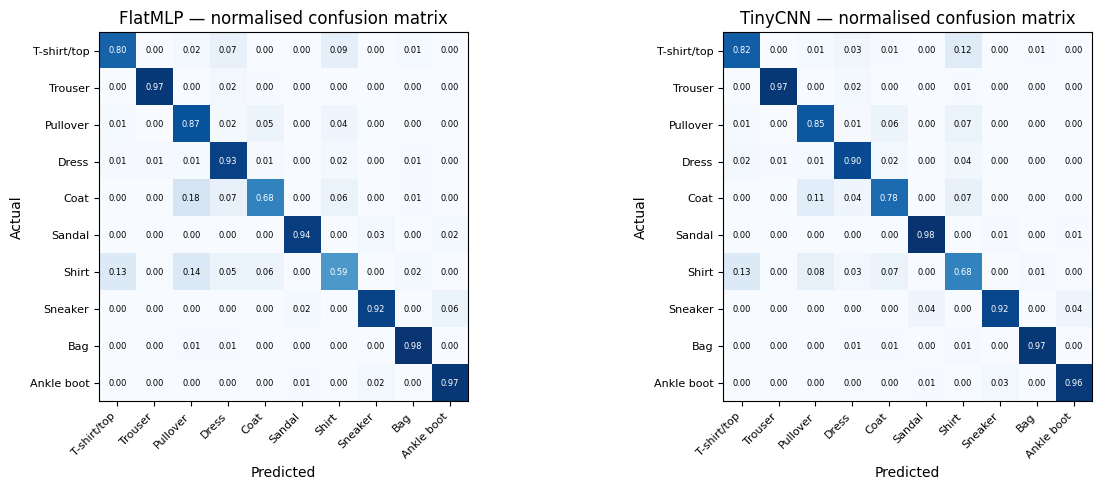

In [9]:
# A confusion matrix shows WHERE each model makes mistakes: for every true class, which class did
# it predict? The diagonal = correct predictions; off-diagonal cells = specific confusions.
# We build one for the MLP and one for the CNN, then plot them side by side.
from sklearn.metrics import confusion_matrix

# Collect the true labels and the model's predictions across the whole test set.
def predictions(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            ## NEW FOR GPU: Move the data to GPU before prediction starts.
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            ## NEW FOR GPU. This is trigger device error cos numpy() cannot access GPU memory.
            ## ps.append(logits.argmax(dim=1).numpy())   # predicted class per image
            ## NEW FOR GPU. Calling cpu() will implicitly move the predictions (logits) from GPU to CPU before
            ## converting to numpy.
            ps.append(logits.cpu().argmax(dim=1).numpy())
            ## ys.append(yb.numpy())                      # true class per image
            ## NEW FOR GPU.
            ys.append(yb.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps)      # stitch the batches into one long array

y_true, mlp_preds = predictions(mlp, test_loader)
_,      cnn_preds = predictions(cnn, test_loader)      # true labels are the same, so we ignore them here

# normalize='true' turns counts into fractions per row, so each cell reads as "of all the real Xs,
# what fraction did the model call Y?" This makes classes comparable regardless of how many samples each has.
cm_mlp = confusion_matrix(y_true, mlp_preds, normalize='true')
cm_cnn = confusion_matrix(y_true, cnn_preds, normalize='true')

# Draw the two matrices as heatmaps (darker = higher fraction).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, title in [(axes[0], cm_mlp, 'FlatMLP'), (axes[1], cm_cnn, 'TinyCNN')]:
    im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f"{title} — normalised confusion matrix")
    # Write the numeric value inside each cell (white text on dark cells for readability).
    for i in range(10):
        for j in range(10):
            txt = ax.text(j, i, f"{cm[i,j]:.2f}",
                          ha='center', va='center',
                          fontsize=6,
                          color='white' if cm[i,j] > 0.5 else 'black')
plt.tight_layout()
plt.show()

**Read the diagonals carefully — the win is uneven.** On this run:

- **Shirt** is the hardest class for *both* models (≈0.58–0.60 correct), and the CNN barely moves it (about +0.01). So the CNN does **not** rescue the single hardest class — a useful reality check.
- The CNN's real gains are on other structured garments: **Dress** (≈0.84 → 0.88) and **Pullover** (≈0.74 → 0.84).
- It's not a free lunch: the CNN can actually do *worse* on a class — here **T-shirt/top** drops (≈0.89 → 0.87), some of it traded into better Pullover/Shirt separation.

The headline (~+1.4pp overall) is the **net** of these per-class gains and losses, not a uniform lift. The spatial-feature advantage is real, but on an easy grayscale dataset it shows up as modest, uneven improvements — the gap widens on harder data (CIFAR-10 in the assignment). *Your exact numbers will vary slightly per run.*

## 7 · Visualise what the first conv layer learned

The `Conv2d` layer's weights ARE the learned kernels. After training, what do those 16 kernels look like?

Learned kernels shape: (16, 1, 3, 3)


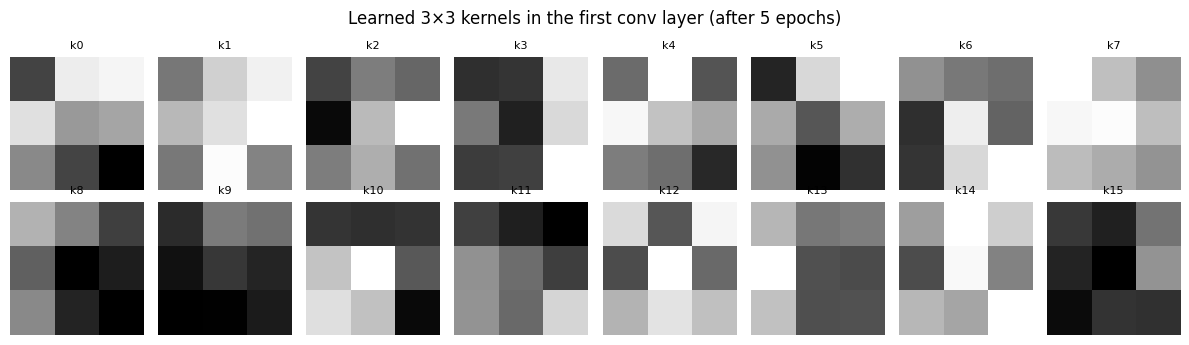

In [10]:
# Peek inside the trained model: the first conv layer's weights ARE the 16 little 3x3 filters
# it learned. Let's pull them out and display them as tiny images to see what patterns it hunts for.
first_layer = cnn.features[0]  # index 0 of the "features" Sequential is the first Conv2d
# .detach() removes it from gradient tracking, .cpu() moves it off any GPU, .numpy() converts to a NumPy array.
weights = first_layer.weight.detach().cpu().numpy()  # shape (16, 1, 3, 3): 16 filters, 1 channel, 3x3 each
print(f"Learned kernels shape: {weights.shape}")

# Lay the 16 filters out in a 2-row x 8-column grid.
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    k = weights[i, 0]              # the i-th filter as a 3x3 grid of numbers
    vmax = np.abs(k).max()         # scale so the strongest value maps to pure black/white
    # Centre the colour scale at 0 so negatives and positives are equally visible (gray = near zero).
    ax.imshow(k, cmap='gray', vmin=-vmax, vmax=vmax)
    ax.set_title(f"k{i}", fontsize=8)
    ax.axis('off')
plt.suptitle("Learned 3×3 kernels in the first conv layer (after 5 epochs)")
plt.tight_layout()
plt.show()

**Match the picture to the categories.** The grid is laid out k0–k7 (top row) then k8–k15 (bottom row). On this trained model (seed 42), the kernels sort into the families we predicted in NB 02 — here's how to read them, by their dominant light→dark direction:

- **Vertical-edge detectors** (one side light, the other dark — they fire on left/right edges): the clearest are **k14, k2, k12** (light stripe on the *left*) and **k8, k10** (light stripe on the *right*). These are the strongest filters in the bank.
- **Horizontal-edge detectors** (light top vs dark bottom or vice-versa — they fire on top/bottom edges): **k15** (light *below*), plus **k13** and **k6** (light *above*).
- **Centre-surround detector** (middle pixel opposite to its ring — fires on spots/blobs): **k0** has a dark centre with a brighter surround.
- **Low-contrast / texture-ish**: a few (e.g. **k1, k4**) are fainter and more mixed — these respond to gentler gradients and fine texture rather than a single crisp edge.

So the bank is mostly a set of **oriented edge detectors at different angles**, exactly like NB 02's hand-built edge and Sobel kernels — except **nobody specified them**; they emerged purely from training on labelled images. *(Exact k-indices depend on the random seed; if you retrain, the same families appear but in different slots.)*

## 8 · Inspect the activation maps for a real image

Let's pick one image and look at the 16 feature maps the trained first layer produces for it. Now we can see the kernels *in action*.

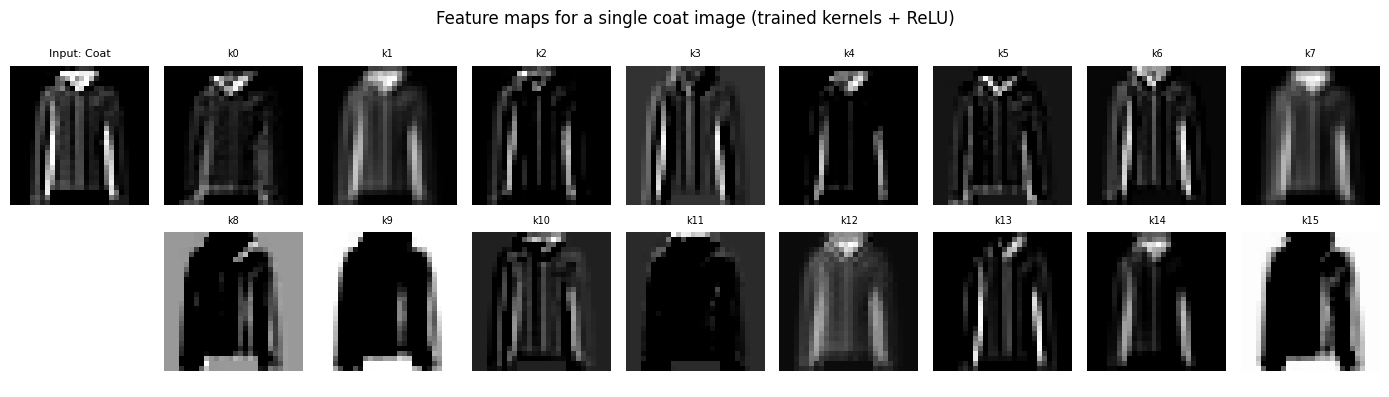

In [11]:
# Filters are abstract on their own, so let's see them WORKING. We run one real image through the
# first conv layer and view the 16 resulting "feature maps" — each one highlights wherever its
# filter found its pattern (an edge, a texture, etc.) in the image.

# Find the first test image whose label is 4 (a Coat). next(...) grabs the first match from the generator.
idx = next(i for i, (_, y) in enumerate(test_ds) if y == 4)
img, lbl = test_ds[idx]
## NEW FOR GPU: Must move the images/data to the same device as model because the model is stll in GPU!!!
## So this statement will cause device error!!!
## img_batched = img.unsqueeze(0)        # models expect a batch, so add a batch dimension: (1, 1, 28, 28)
## NEW FOR GPU: match model device.
img_batched = img.unsqueeze(0).to(device)

with torch.no_grad():
    fmaps = cnn.features[0](img_batched).squeeze(0)  # run only the first conv layer -> 16 maps of 28x28
    fmaps = torch.relu(fmaps)                         # apply ReLU, exactly as the full model would

# Plot the original image plus all 16 feature maps.
fig, axes = plt.subplots(2, 9, figsize=(14, 4))
# Show the input image itself in the top-left corner for reference.
axes[0,0].imshow(img.squeeze(), cmap='gray')          # squeeze() drops the size-1 channel dim for plotting
axes[0,0].set_title(f"Input: {CLASSES[lbl]}", fontsize=8)
axes[0,0].axis('off')
axes[1,0].axis('off')                                 # leave the bottom-left corner blank

for i in range(16):
    row = (i // 8)                    # first 8 maps go on row 0, next 8 on row 1
    col = (i % 8) + 1                 # +1 to skip the corner reserved for the input image
    ## axes[row, col].imshow(fmaps[i].numpy(), cmap='gray')
    ## NEW FOR GPU: move back to CPU for matplotlib.
    axes[row, col].imshow(fmaps[i].cpu().numpy(), cmap='gray')
    axes[row, col].set_title(f"k{i}", fontsize=7)
    axes[row, col].axis('off')

plt.suptitle('Feature maps for a single coat image (trained kernels + ReLU)')
plt.tight_layout()
plt.show()

Each feature map highlights a different aspect of the coat: outlines, sleeve edges, internal texture. Stack a second conv block on top of these and you'd see kernels that combine features — e.g., "left sleeve + collar," "high-contrast vertical seam."

That **compositionality** is what makes deeper CNNs more powerful. The shallow features detect edges; deeper features detect parts; deepest features detect whole categories.

## 9 · Save the model and recap

In [12]:
# Save the trained model and print a final recap.
# state_dict() is just the learned weights (not the code) — the standard way to save a PyTorch model.
# You can later reload these weights into a fresh TinyCNN() without retraining.
torch.save(cnn.state_dict(), 'tiny_cnn.pt')
print('Saved: tiny_cnn.pt')

# Final side-by-side scoreboard of the two models.
print(f"\nFinal scores:")
print(f"  FlatMLP : {mlp_acc:.4f}  (235K params)")
print(f"  TinyCNN : {cnn_acc:.4f}  ({n_params/1000:.0f}K params)")
print(f"\nThe CNN beats the MLP using fewer parameters, by exploiting the spatial structure of pixels.")

Saved: tiny_cnn.pt

Final scores:
  FlatMLP : 0.8661  (235K params)
  TinyCNN : 0.8833  (106K params)

The CNN beats the MLP using fewer parameters, by exploiting the spatial structure of pixels.


**This is the punchline of L08 so far:**

- Conv layers learn small kernels (edge detectors, texture detectors, etc.) from data.
- Stacking them builds hierarchical visual features.
- The same kernel reused across the image gives translation invariance and parameter efficiency.
- The PyTorch training loop is unchanged — only the architecture is.

**Next:** what happens when you only have 500 photos per class instead of 6000? That's the realistic Sarah scenario. We turn to **transfer learning** in NB 04.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · Train longer — does accuracy keep improving?

We trained 5 epochs to keep the notebook fast. What if you train 15? Make a copy of `cnn` and continue. Plot test accuracy per epoch. You should see diminishing returns and eventually a slight over-fit (train accuracy keeps climbing, test accuracy plateaus or dips).

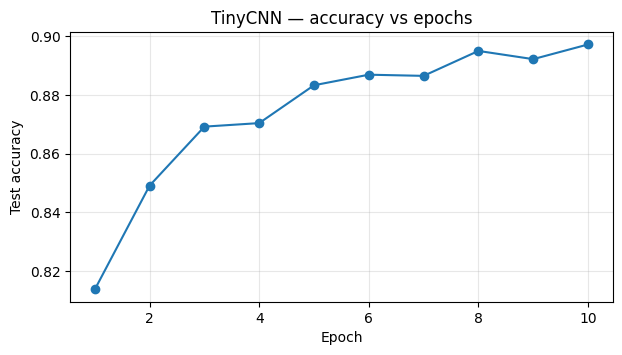

Best test acc over 10 epochs: 0.8972


In [13]:
# Extension: does training longer help? We build a FRESH CNN (so the earlier one isn't affected)
# and train it for 10 epochs, recording test accuracy after each one to see the trend.
cnn2 = TinyCNN()                                   # brand-new model with random starting weights
## NEW FOR GPU: Push model BEFORE optimizer.
cnn2 = cnn2.to(device)
opt2 = torch.optim.Adam(cnn2.parameters(), lr=LR)
accs = []                                          # test accuracy after each epoch
for epoch in range(1, 11):                         # 10 epochs this time
    cnn2.train()
    for xb, yb in train_loader:
        ## NEW FOR GPU.
        xb, yb = xb.to(device), yb.to(device)
        opt2.zero_grad()
        loss = criterion(cnn2(xb), yb)
        loss.backward()
        opt2.step()
    accs.append(evaluate(cnn2, test_loader))       # record accuracy at the end of this epoch

# Plot accuracy vs epoch — you'll typically see fast early gains, then diminishing returns.
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, 11), accs, marker='o')
plt.xlabel('Epoch'); plt.ylabel('Test accuracy')
plt.title('TinyCNN — accuracy vs epochs')
plt.grid(alpha=0.3)
plt.show()
print(f"Best test acc over 10 epochs: {max(accs):.4f}")

## E2 · A deeper CNN with three conv blocks

Does adding a third Conv block help? Build a `DeeperCNN(1 → 16 → 32 → 64)` and compare.

In [ ]:
# Extension: try a deeper CNN with THREE conv blocks instead of two. Does more depth automatically
# mean better? We'll train it and compare to TinyCNN — the answer may surprise you.
class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # block 1: 28x28 -> 14x14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # block 2: 14x14 -> 7x7
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),                   # block 3: 64 feature maps
            # AdaptiveAvgPool2d(1) shrinks each feature map to a single average value -> just 64 numbers.
            # This is compact but throws away a lot of spatial detail (a key reason it underperforms here).
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 10),       # tiny classifier: 64 features -> 10 classes
        )
    def forward(self, x):
        return self.head(self.features(x))

deep = DeeperCNN()
## NEW FOR GPU: Push model BEFORE optimizer.
deep = deep.to(device)
deep_opt = torch.optim.Adam(deep.parameters(), lr=LR)
print(f"DeeperCNN params: {sum(p.numel() for p in deep.parameters()):,}")  # note: fewer params than TinyCNN!

# Train for the same 5 epochs so the comparison is fair.
for epoch in range(1, 6):
    deep.train()
    for xb, yb in train_loader:
        ## NEW FOR GPU.
        xb, yb = xb.to(device), yb.to(device)
        deep_opt.zero_grad()
        loss = criterion(deep(xb), yb)
        loss.backward()
        deep_opt.step()
deep_acc = evaluate(deep, test_loader)
print(f"DeeperCNN final test acc: {deep_acc:.4f}")
print(f"TinyCNN   final test acc: {cnn_acc:.4f}")        # deeper isn't always better — see the note below

DeeperCNN params: 23,946
DeeperCNN final test acc: 0.7721
TinyCNN   final test acc: 0.8843


**Interesting result.** Notice that this `DeeperCNN` actually *underperforms* `TinyCNN` here. Why?

Two reasons:
1. **Capacity** — `DeeperCNN` has fewer parameters (~24K vs ~106K) because the global-average-pool collapses to just 64 features before the head. Less capacity for the same task.
2. **Underfitting in 5 epochs** — deeper nets often need more epochs to catch up, and the wider classifier head in TinyCNN converges faster on this easy dataset.

The lesson: **more depth is not automatically better.** Depth + width + capacity must all match the dataset's complexity. On CIFAR-10 (the assignment) depth pays off more because the dataset is harder.